## 1. Environment setup

Run this once. If `gudhi`/`ripser` fail to build on Windows, use `conda install -c conda-forge gudhi ripser` instead of pip.

In [1]:
!pip install numpy pandas matplotlib scikit-learn ripser persim gudhi tqdm
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from ripser import ripser
from persim import PersistenceImager
from tqdm.auto import tqdm

np.random.seed(42)
print("Environment OK")


Environment OK


## 2. Configuration

All paths and hyperparameters live here so you only edit one place.

In [3]:
DATA_DIR = Path("data")            # where train/, test/, labeled_anomalies.csv live
TRAIN_DIR = DATA_DIR / "train"
TEST_DIR = DATA_DIR / "test"
LABELS_CSV = DATA_DIR / "labeled_anomalies.csv"

WINDOW_SIZE = 100      # number of timesteps per window
STRIDE = 20            # step between window starts
EMBED_DIM = 3          # Takens embedding dimension
EMBED_DELAY = 5        # Takens embedding delay
ANOMALY_FRACTION_THRESHOLD = 0.2   # window labeled anomalous if >20% of its points are anomalous

OUTPUT_DIR = Path("processed")
OUTPUT_DIR.mkdir(exist_ok=True)


## 3. Download the dataset

Run this cell **once**, on a machine with normal internet access. It downloads the official Telemanom release (used by the SMAP/MSL benchmark) and the ground-truth label file.

If `data/` already exists, this cell skips the download.


In [5]:
import os
print(os.getcwd())

C:\Users\divya\OneDrive\Documents\NASA SMAP


In [6]:
import zipfile, os
import urllib.request

if not DATA_DIR.exists():
    print("Downloading dataset (this can take a few minutes)...")
    try:
        url = "https://s3-us-west-2.amazonaws.com/telemanom/data.zip"
        urllib.request.urlretrieve(url, "data.zip")
        with zipfile.ZipFile("data.zip", "r") as z:
            z.extractall(".")
        os.remove("data.zip")
        urllib.request.urlretrieve(
            "https://raw.githubusercontent.com/khundman/telemanom/master/labeled_anomalies.csv",
            str(LABELS_CSV),
        )
        print("Dataset downloaded and extracted!")
    except Exception as e:
        print("Download failed (no internet access from this machine/network, or the host is blocked).")
        print("Error:", e)
        print("-> The next cell will generate small synthetic demo data instead, so you can still test the pipeline.")
        print("-> Once you have internet access, delete any partial 'data/' folder and re-run this cell.")
else:
    print("data/ already exists, skipping download.")


data/ already exists, skipping download.


## 4. Demo/fallback data (only runs if the real dataset isn't present yet)

This generates a couple of fake channels with the **exact same file layout** as the real dataset (`train/<chan_id>.npy`, `test/<chan_id>.npy`, `labeled_anomalies.csv` with matching columns), so you can test steps 5–9 immediately. **Skip this cell once you have the real data downloaded** — it will not overwrite real data.


In [8]:
if not DATA_DIR.exists():
    print("Real dataset not found — generating synthetic demo data instead.")
    TRAIN_DIR.mkdir(parents=True, exist_ok=True)
    TEST_DIR.mkdir(parents=True, exist_ok=True)

    demo_channels = []
    rng = np.random.default_rng(0)
    for i, chan_id in enumerate(["DEMO-1", "DEMO-2"]):
        t_train = np.linspace(0, 80, 4000)
        t_test = np.linspace(0, 40, 2000)
        train_signal = np.sin(t_train) + 0.05 * rng.standard_normal(len(t_train))
        test_signal = np.sin(t_test) + 0.05 * rng.standard_normal(len(t_test))

        # inject one contextual anomaly into the test signal
        a_start, a_end = 900, 1100
        test_signal[a_start:a_end] = np.sin(t_test[a_start:a_end] * 4) + 0.05 * rng.standard_normal(a_end - a_start)

        # pad with a couple of dummy one-hot "command" columns like the real dataset
        train_arr = np.column_stack([train_signal, np.zeros((len(train_signal), 2))])
        test_arr = np.column_stack([test_signal, np.zeros((len(test_signal), 2))])

        np.save(TRAIN_DIR / f"{chan_id}.npy", train_arr)
        np.save(TEST_DIR / f"{chan_id}.npy", test_arr)

        demo_channels.append({
            "chan_id": chan_id,
            "spacecraft": "DEMO",
            "anomaly_sequences": str([[a_start, a_end]]),
            "class": "contextual",
            "num_values": len(test_signal),
        })

    pd.DataFrame(demo_channels).to_csv(LABELS_CSV, index=False)
    print("Synthetic demo data created under data/.")
else:
    print("Real data present — nothing to generate.")


Real data present — nothing to generate.


## 5. Load channel metadata and anomaly labels

In [10]:
import ast

labels_df = pd.read_csv(LABELS_CSV)
labels_df["anomaly_sequences"] = labels_df["anomaly_sequences"].apply(ast.literal_eval)
labels_df.head()


,chan_id,spacecraft,anomaly_sequences,class,num_values
0,P-1,SMAP,"[[2149, 2349], [4536, 4844], [3539, 3779]]","[contextual, contextual, contextual]",8505
1,S-1,SMAP,"[[5300, 5747]]",[point],7331
2,E-1,SMAP,"[[5000, 5030], [5610, 6086]]","[contextual, contextual]",8516
3,E-2,SMAP,"[[5598, 6995]]",[point],8532
4,E-3,SMAP,"[[5094, 8306]]",[point],8307


## 6. Sanity-check: load and plot one channel

Confirms the data loads correctly and the labeled anomaly region actually looks different from normal behavior.

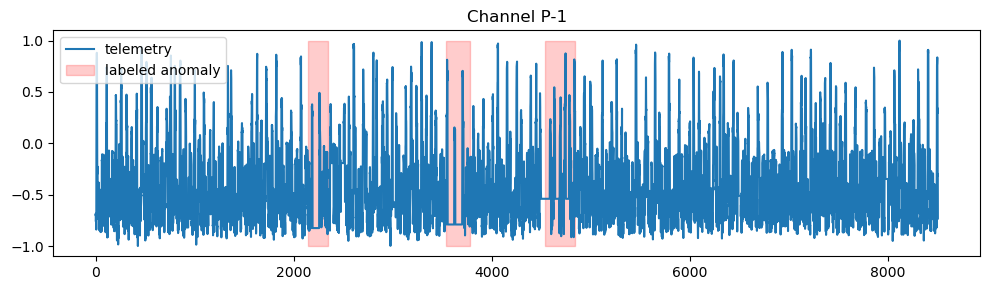

In [12]:
def load_channel(chan_id, split="test"):
    folder = TRAIN_DIR if split == "train" else TEST_DIR
    arr = np.load(folder / f"{chan_id}.npy")
    signal = arr[:, 0]   # first column = actual telemetry value; remaining columns = command one-hots
    return signal

def make_point_labels(chan_id, n_points):
    row = labels_df[labels_df["chan_id"] == chan_id].iloc[0]
    point_labels = np.zeros(n_points, dtype=int)
    for start, end in row["anomaly_sequences"]:
        point_labels[start:end] = 1
    return point_labels

demo_chan = labels_df.iloc[0]["chan_id"]
signal = load_channel(demo_chan, split="test")
point_labels = make_point_labels(demo_chan, len(signal))

plt.figure(figsize=(10, 3))
plt.plot(signal, label="telemetry")
plt.fill_between(np.arange(len(signal)), signal.min(), signal.max(),
                  where=point_labels.astype(bool), color="red", alpha=0.2, label="labeled anomaly")
plt.title(f"Channel {demo_chan}")
plt.legend()
plt.tight_layout()
plt.show()


## 7. Sliding windows

Each channel's signal is split into overlapping fixed-length windows. A window is labeled anomalous if more than `ANOMALY_FRACTION_THRESHOLD` of its points fall inside a labeled anomaly region.

In [14]:
def sliding_windows(x, window_size, stride):
    n = len(x)
    starts = np.arange(0, n - window_size + 1, stride)
    windows = np.array([x[s:s + window_size] for s in starts])
    return windows, starts

def window_labels_from_points(point_labels, starts, window_size, threshold):
    labels = []
    for s in starts:
        frac = point_labels[s:s + window_size].mean()
        labels.append(1 if frac > threshold else 0)
    return np.array(labels)

windows, starts = sliding_windows(signal, WINDOW_SIZE, STRIDE)
win_labels = window_labels_from_points(point_labels, starts, WINDOW_SIZE, ANOMALY_FRACTION_THRESHOLD)
print(f"{windows.shape[0]} windows built, {win_labels.sum()} labeled anomalous")


421 windows built, 47 labeled anomalous


## 8. Takens' delay embedding + persistent homology

Each 1-D window is turned into a point cloud in `EMBED_DIM`-dimensional space using delay coordinates. Persistent homology (via `ripser`) is then computed on that point cloud — this captures the *shape* of the local dynamics (loops, connected components) rather than just raw magnitude, which is what should make TDA sensitive to contextual anomalies that simple thresholds miss.


In [16]:
def takens_embedding(window, dim=EMBED_DIM, delay=EMBED_DELAY):
    n = len(window) - (dim - 1) * delay
    if n <= 0:
        raise ValueError("Window too short for the chosen embedding dimension/delay.")
    return np.array([window[i: i + (dim - 1) * delay + 1: delay] for i in range(n)])

def compute_h1_diagram(window):
    cloud = takens_embedding(window)
    dgms = ripser(cloud, maxdim=1)["dgms"]
    h1 = dgms[1]
    if len(h1) == 0:
        h1 = np.empty((0, 2))
    return h1

# quick check on one window
example_dgm = compute_h1_diagram(windows[0])
print("Example H1 diagram (birth, death) pairs:\n", example_dgm)


Example H1 diagram (birth, death) pairs:
 [[1.03609085 1.07738554]
 [1.03239274 1.12587631]
 [0.96645653 1.04192126]
 [0.95139903 1.12978959]
 [0.47944471 0.54416955]
 [0.4170084  0.42518625]
 [0.39938357 0.41966537]
 [0.29664338 0.29894873]
 [0.28687587 0.33353439]
 [0.26520109 0.2968877 ]
 [0.24791634 0.26464543]
 [0.23614031 0.24367705]
 [0.2102029  0.22606406]
 [0.17195903 0.18536218]
 [0.16054028 0.16533034]
 [0.15544987 0.184591  ]
 [0.15059331 0.17971499]
 [0.13584121 0.14741033]
 [0.12714425 0.15047722]
 [0.12436834 0.13561495]
 [0.11971907 0.13716732]
 [0.08392593 0.09099468]]


## 9. Run the full pipeline over every channel

This loops over all channels in `labeled_anomalies.csv`, builds windows, computes an H1 persistence diagram per window, and collects everything together. This is the slow step — persistent homology is computed independently for every window, so runtime scales with (number of channels × number of windows per channel).


In [18]:
all_diagrams = []
all_win_labels = []
all_chan_ids = []

for _, row in tqdm(labels_df.iterrows(), total=len(labels_df), desc="Channels"):
    chan_id = row["chan_id"]
    try:
        sig = load_channel(chan_id, split="test")
    except FileNotFoundError:
        print(f"Skipping {chan_id}: file not found")
        continue

    pt_labels = make_point_labels(chan_id, len(sig))
    wins, starts = sliding_windows(sig, WINDOW_SIZE, STRIDE)
    if len(wins) == 0:
        continue
    w_labels = window_labels_from_points(pt_labels, starts, WINDOW_SIZE, ANOMALY_FRACTION_THRESHOLD)

    for w, lbl in zip(wins, w_labels):
        try:
            dgm = compute_h1_diagram(w)
        except ValueError:
            continue
        all_diagrams.append(dgm)
        all_win_labels.append(lbl)
        all_chan_ids.append(chan_id)

all_win_labels = np.array(all_win_labels)
print(f"Total windows processed: {len(all_diagrams)}  |  anomalous: {all_win_labels.sum()}")


Channels:   0%|          | 0/82 [00:00<?, ?it/s]

Total windows processed: 25522  |  anomalous: 3459


In [19]:

# failed_windows = 0
# failed_anomalous = 0
# failed_normal = 0

# total_windows = 0

# for _, row in tqdm(labels_df.iterrows(), total=len(labels_df), desc="Channels"):
#     chan_id = row["chan_id"]

#     try:
#         sig = load_channel(chan_id, split="test")
#     except FileNotFoundError:
#         print(f"Skipping {chan_id}: file not found")
#         continue

#     pt_labels = make_point_labels(chan_id, len(sig))
#     wins, starts = sliding_windows(sig, WINDOW_SIZE, STRIDE)

#     if len(wins) == 0:
#         continue

#     w_labels = window_labels_from_points(
#         pt_labels,
#         starts,
#         WINDOW_SIZE,
#         ANOMALY_FRACTION_THRESHOLD
#     )

#     for w, lbl in zip(wins, w_labels):

#         total_windows += 1

#         try:
#             dgm = compute_h1_diagram(w)

#         except ValueError as e:
#             failed_windows += 1

#             if lbl == 1:
#                 failed_anomalous += 1
#             else:
#                 failed_normal += 1

#             continue

# print("\n===== TDA FAILURE CHECK =====")
# print(f"Total windows attempted: {total_windows}")
# print(f"Successful diagrams:    {total_windows - failed_windows}")
# print(f"Failed diagrams:        {failed_windows}")

# if total_windows > 0:
#     print(f"Failure percentage:     {failed_windows / total_windows * 100:.2f}%")

# print(f"\nFailed anomalous windows: {failed_anomalous}")
# print(f"Failed normal windows:    {failed_normal}")



In [20]:
import pickle

with open("processed/tda_results.pkl", "wb") as f:
    pickle.dump(
        {
            "diagrams": all_diagrams,
            "labels": all_win_labels,
            "channels": all_chan_ids
        },
        f
    )

print("Saved successfully!")

Saved successfully!


## 10. Vectorize diagrams into fixed-length feature vectors

`PersistenceImager` is fit **once on the entire collection** of diagrams (not per-window) so that every window's diagram is mapped into the *same* coordinate grid — this is what makes the output usable as a fixed-length feature vector for a downstream model.


In [22]:
empty_count = sum(len(dgm) == 0 for dgm in all_diagrams)

print("Total diagrams:", len(all_diagrams))
print("Empty H1 diagrams:", empty_count)
print("Non-empty H1 diagrams:", len(all_diagrams) - empty_count)

Total diagrams: 25522
Empty H1 diagrams: 9648
Non-empty H1 diagrams: 15874


In [23]:
non_empty_diagrams = [dgm for dgm in all_diagrams if len(dgm) > 0]

print("Non-empty diagrams:", len(non_empty_diagrams))

pimgr = PersistenceImager(pixel_size=0.1)
pimgr.fit(non_empty_diagrams)

print("Pixel size:", pimgr.pixel_size)
print("Birth range:", pimgr.birth_range)
print("Persistence range:", pimgr.pers_range)

Non-empty diagrams: 15874
Pixel size: 0.1
Birth range: (-0.03882892085603107, 2.8611710791439693)
Persistence range: (-0.042185938356487984, 1.6578140616435122)


In [24]:
# Separate empty and non-empty diagrams
non_empty_diagrams = [
    dgm for dgm in all_diagrams
    if len(dgm) > 0
]

# Fit the PersistenceImager only on non-empty diagrams
pimgr = PersistenceImager(pixel_size=0.1)
pimgr.fit(non_empty_diagrams)

# Get the image shape from one non-empty diagram
example_image = pimgr.transform([non_empty_diagrams[0]])[0]

print("Persistence image shape:", example_image.shape)

# Create persistence images for ALL windows
images = []

for dgm in all_diagrams:
    if len(dgm) == 0:
        # No H1 features → zero persistence image
        img = np.zeros_like(example_image)
    else:
        img = pimgr.transform([dgm])[0]

    images.append(img)

images = np.array(images)

print("Final images shape:", images.shape)

# Flatten each image into a feature vector
feature_vectors = images.reshape(images.shape[0], -1)

print("Feature vectors shape:", feature_vectors.shape)

Persistence image shape: (29, 17)
Final images shape: (25522, 29, 17)
Feature vectors shape: (25522, 493)


## 11. Save processed features for training in Colab

These are the only files you need to upload to Google Drive — no need to bring the raw dataset into Colab at all.


In [26]:
np.save(OUTPUT_DIR / "X_features.npy", feature_vectors)
np.save(OUTPUT_DIR / "y_labels.npy", all_win_labels)
np.save(OUTPUT_DIR / "chan_ids.npy", np.array(all_chan_ids))

print("Saved to:", OUTPUT_DIR.resolve())
print(" - X_features.npy:", feature_vectors.shape)
print(" - y_labels.npy:", all_win_labels.shape)


Saved to: C:\Users\divya\OneDrive\Documents\NASA SMAP\processed
 - X_features.npy: (25522, 493)
 - y_labels.npy: (25522,)


## Next steps

1. Upload the `processed/` folder to a Google Drive folder (e.g. `satellite-tda-project/`).
2. In Colab: `from google.colab import drive; drive.mount('/content/drive')`
3. Load with `np.load('/content/drive/MyDrive/satellite-tda-project/X_features.npy')`
4. Train your LSTM / GNN / NeuroTopoGCB-style model on `X_features` (optionally combined with raw window statistics) against `y_labels`, using a train/validation split by `chan_id` (not randomly — keep windows from the same channel together) to avoid leakage.
5. Evaluate with a point-adjust F1 metric consistent with the SMAP/MSL literature, since a single correctly flagged point within a true anomalous region is usually counted as detecting the whole event.
